## 작업내용
1. 데이터 로드
- battery_cycles_labeled.parquet를 재활용.
- is_modeling_cycle == True인 cycle만 사용.
- 07번에서 만든 rolling_scenarios.csv를 그대로 사용.

2. 개선 target 생성
- 기존 target: capacity_ah
- 개선 target 1: capacity_ewm_span_9(신규 파생 target)
- 개선 target 2: capacity_roll_median_7(신규 파생 target)
- 각 target별 SoH도 함께 계산.

3. 이상 drop 영향 확인
- cycle 516 근처처럼 capacity가 갑자기 떨어지는 구간을 확인.
- raw capacity에서는 EOL로 보일 수 있지만, sustained EOL 기준에서는 실제 EOL이 아닌지 확인.

4. target별 rolling forecast 실행
- 같은 scenario에서 capacity_ah, capacity_ewm_span_9, capacity_roll_median_7을 각각 예측.
- 우선 ML 계열로만 비교.
- 추천 모델은 Persistence, MovingAverage, RidgeRegression, RandomForestRegressor.

5. 결과 비교
- target 기준 MAE/RMSE를 비교.
- raw capacity 기준 MAE/RMSE도 같이 비교.
- EOL crossing 구간에서 RUL 탐지가 좋아졌는지 확인.

6. calibration 확인
- TimesFM/Chronos/NHITS/PatchTST의 p10-p90 band가 실제값을 충분히 포함하는지 확인.
- coverage가 낮으면 uncertainty band가 너무 좁은 것을 의미.
- coverage가 너무 높고 band가 넓으면 실무 의사결정에는 불확실성이 큰 모델.

## 체크사항
- 07번과 동일한 rolling scenario를 사용했는가?
- smoothing 계산에 미래 cycle 정보가 들어가지 않았는가?
- center=True rolling을 사용하지 않았는가?
- raw capacity와 smoothed capacity를 같은 기준으로 비교했는가?
- cycle 516의 일시적 drop이 smoothing에서 완화되는가?
- EOL/RUL 평가는 기존과 동일하게 80% threshold + 5-cycle sustained 기준인가?
- capacity MAE가 좋아진 것과 RUL 탐지가 좋아진 것을 구분해서 해석했는가?
- 결과 저장 파일명이 기존 05/06/07 산출물과 구분되는가?

In [1]:
# 설정 및 데이터 로드
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
pd.set_option("display.max_columns", 100)
PROJECT_ROOT = Path("..").resolve()

LABELED_PARQUET_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "paraquet"
    / "battery_cycles_labeled.parquet"
)

SCENARIO_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "csv"
    / "evaluation"
    / "rolling_scenarios.csv"
)

IMPROVEMENT_CSV_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "csv"
    / "evaluation"
    / "improvement"
)

IMPROVEMENT_PARQUET_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "parquet"
    / "evaluation"
    / "improvement"
)
IMPROVEMENT_CSV_DIR.mkdir(parents=True, exist_ok=True)
IMPROVEMENT_PARQUET_DIR.mkdir(parents=True, exist_ok=True)

battery_cycles = pd.read_parquet(LABELED_PARQUET_PATH)
scenarios = pd.read_csv(SCENARIO_PATH)

series_df = (
    battery_cycles[battery_cycles["is_modeling_cycle"]]
    .sort_values("cycle")
    .reset_index(drop=True)
    .copy()
)

INITIAL_CAPACITY = float(series_df["initial_capacity"].dropna().iloc[0])
EOL_THRESHOLD = float(series_df["eol_threshold"].dropna().iloc[0])
EOL_CONFIRMATION_CYCLES = int(
    series_df["eol_confirmation_cycles"].dropna().iloc[0]
)
TRUE_EOL_CYCLE = int(series_df["eol_cycle"].dropna().iloc[0])

print("project root:", PROJECT_ROOT)
print("series shape:", series_df.shape)
print("scenario shape:", scenarios.shape)
print("initial capacity:", INITIAL_CAPACITY)
print("true EOL cycle:", TRUE_EOL_CYCLE)

project root: /Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis
series shape: (868, 38)
scenario shape: (15, 18)
initial capacity: 1.1364220858837624
true EOL cycle: 546


In [5]:
# 08-2. raw capacity와 smoothing target 생성

# raw capacity는 기존 모델링 타깃.
series_df["capacity_raw"] = series_df["capacity_ah"]

# EWM은 과거 값만 사용하는 causal smoothing을 의미.
# center=True rolling을 쓰면 미래 정보를 보게 되므로 여기서는 사용하지 않음.
series_df["capacity_ewm_span_9"] = (
    series_df["capacity_ah"]
    .ewm(span=9, adjust=False)
    .mean()
)

# trailing rolling median도 과거 window만 사용.
# 일시적인 1-cycle drop에 덜 민감한 target 후보.
series_df["capacity_roll_median_7"] = (
    series_df["capacity_ah"]
    .rolling(window=7, min_periods=1)
    .median()
)

# 각 target별 SoH도 같이 만듬.
for target_col in [
    "capacity_raw",
    "capacity_ewm_span_9",
    "capacity_roll_median_7",
]:
    series_df[f"soh_{target_col}"] = (
        series_df[target_col]
        / INITIAL_CAPACITY
    )

# 급격한 capacity drop 후보를 진단용으로 표시.
series_df["capacity_delta"] = series_df["capacity_ah"].diff()
series_df["large_drop_candidate"] = (
    series_df["capacity_delta"] < -0.05
)

display(
    series_df[
        [
            "cycle",
            "capacity_ah",
            "capacity_ewm_span_9",
            "capacity_roll_median_7",
            "soh",
            "capacity_delta",
            "large_drop_candidate",
        ]
    ]
    .query("large_drop_candidate")
    .head(20)
)

display(
    series_df[
        [
            "cycle",
            "capacity_ah",
            "capacity_ewm_span_9",
            "capacity_roll_median_7",
            "soh",
            "rul",
            "rul_clipped",
        ]
    ]
    .query("cycle.between(500, 560)")
)

,cycle,capacity_ah,capacity_ewm_span_9,capacity_roll_median_7,soh,capacity_delta,large_drop_candidate
58,59,0.970938,1.059151,1.093605,0.854382,-0.116500,True
124,127,0.902215,1.006939,1.029967,0.793909,-0.122766,True
143,146,0.919805,1.006659,1.028070,0.809387,-0.109414,True
154,157,0.894851,0.984541,1.004459,0.787428,-0.110948,True
166,169,0.881301,0.979560,1.003105,0.775505,-0.119612,True
175,178,0.901432,0.980927,1.005963,0.793219,-0.104532,True
219,222,0.929150,1.020631,1.043749,0.817610,-0.113850,True
230,233,0.886939,0.996599,1.023147,0.780466,-0.128472,True
329,332,0.860024,0.955589,0.973072,0.756782,-0.122745,True
440,444,0.861177,0.955500,0.972098,0.757797,-0.121130,True


,cycle,capacity_ah,capacity_ewm_span_9,capacity_roll_median_7,soh,rul,rul_clipped
495,500,0.933747,0.937078,0.935295,0.821655,46,46
496,501,0.938997,0.937461,0.935295,0.826275,45,45
497,502,0.942545,0.938478,0.935295,0.829397,44,44
498,503,0.943365,0.939456,0.935295,0.830119,43,43
499,504,0.932123,0.937989,0.935295,0.820226,42,42
...,...,...,...,...,...,...,...
551,556,0.902061,0.905461,0.902294,0.793773,-10,0
552,557,0.900491,0.904467,0.902294,0.792391,-11,0
553,558,0.902296,0.904033,0.902294,0.793980,-12,0
554,559,0.906997,0.904625,0.902294,0.798116,-13,0


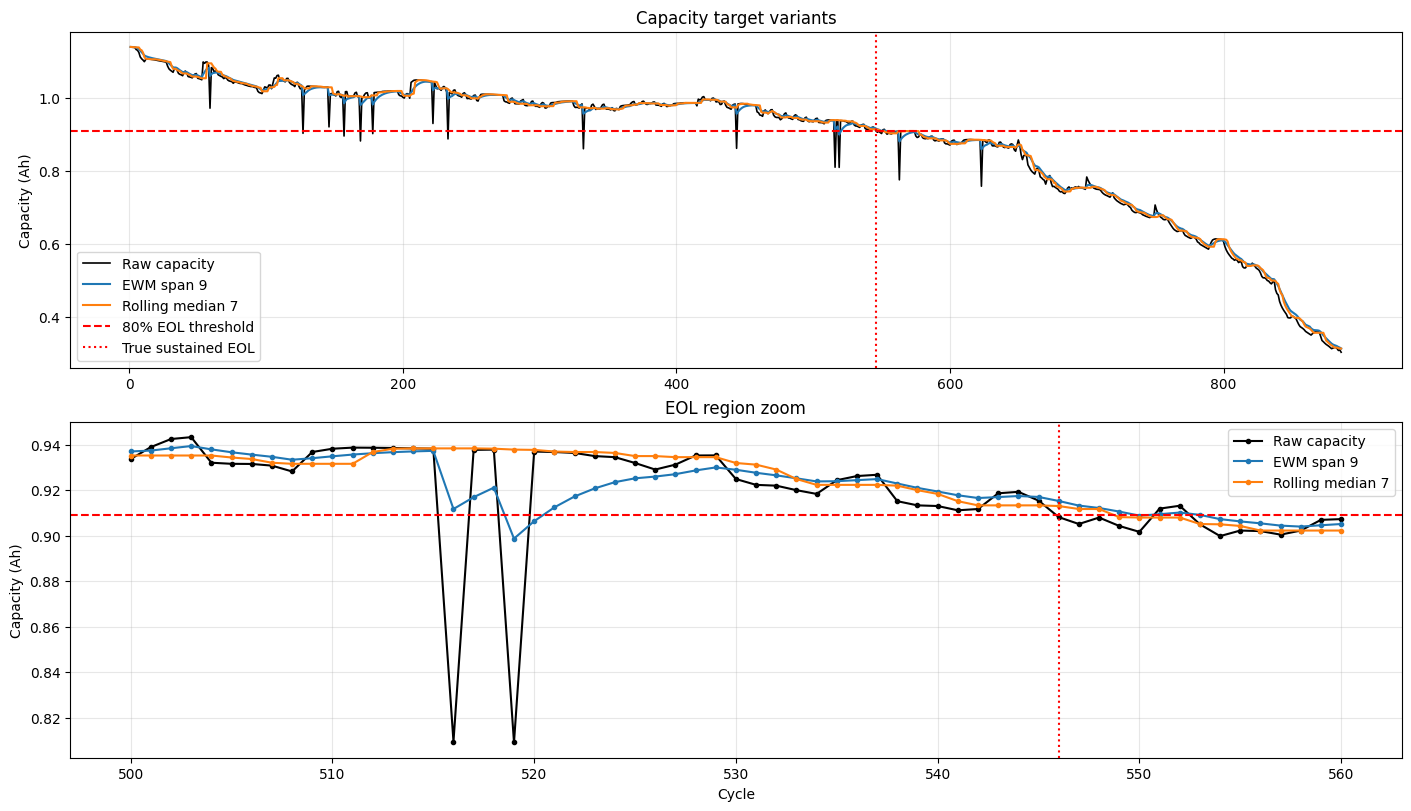

In [6]:
# 08-3. target smoothing 효과 시각화

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=False,
    constrained_layout=True,
)

axes[0].plot(
    series_df["cycle"],
    series_df["capacity_ah"],
    label="Raw capacity",
    color="black",
    linewidth=1.2,
)

axes[0].plot(
    series_df["cycle"],
    series_df["capacity_ewm_span_9"],
    label="EWM span 9",
    color="tab:blue",
    linewidth=1.5,
)

axes[0].plot(
    series_df["cycle"],
    series_df["capacity_roll_median_7"],
    label="Rolling median 7",
    color="tab:orange",
    linewidth=1.5,
)

axes[0].axhline(
    INITIAL_CAPACITY * EOL_THRESHOLD,
    color="red",
    linestyle="--",
    label="80% EOL threshold",
)

axes[0].axvline(
    TRUE_EOL_CYCLE,
    color="red",
    linestyle=":",
    label="True sustained EOL",
)

axes[0].set_title("Capacity target variants")
axes[0].set_ylabel("Capacity (Ah)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

zoom_df = series_df.query("cycle.between(500, 560)")

axes[1].plot(
    zoom_df["cycle"],
    zoom_df["capacity_ah"],
    label="Raw capacity",
    color="black",
    marker="o",
    markersize=3,
)

axes[1].plot(
    zoom_df["cycle"],
    zoom_df["capacity_ewm_span_9"],
    label="EWM span 9",
    color="tab:blue",
    marker="o",
    markersize=3,
)

axes[1].plot(
    zoom_df["cycle"],
    zoom_df["capacity_roll_median_7"],
    label="Rolling median 7",
    color="tab:orange",
    marker="o",
    markersize=3,
)

axes[1].axhline(
    INITIAL_CAPACITY * EOL_THRESHOLD,
    color="red",
    linestyle="--",
)

axes[1].axvline(
    TRUE_EOL_CYCLE,
    color="red",
    linestyle=":",
)

axes[1].set_title("EOL region zoom")
axes[1].set_xlabel("Cycle")
axes[1].set_ylabel("Capacity (Ah)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.show()

### 분석 후 해석포인트
cycle 516에서 raw capacity는 0.809484까지 급락해서 SoH가 0.7123009로 확인됨.
그런데 smoothed target은 drop을 완화하여, 일시적 drop에 너무 민감한 RUL 판단을 줄일 수 있는가를 확인함.

## 개선 진행 1.

In [7]:
# 08-4. target별 rolling forecast 실행

TARGET_CONFIGS = [
    {
        "target_name": "capacity_raw",
        "target_col": "capacity_raw",
        "soh_col": "soh_capacity_raw",
    },
    {
        "target_name": "capacity_ewm_span_9",
        "target_col": "capacity_ewm_span_9",
        "soh_col": "soh_capacity_ewm_span_9",
    },
    {
        "target_name": "capacity_roll_median_7",
        "target_col": "capacity_roll_median_7",
        "soh_col": "soh_capacity_roll_median_7",
    },
]

ML_MODEL_NAMES = [
    "Persistence",
    "MovingAverage",
    "RidgeRegression",
    "RandomForestRegressor",
]

ROLLING_FORECAST_CSV_PATH = (
    IMPROVEMENT_CSV_DIR
    / "target_improvement_rolling_forecasts.csv"
)

ROLLING_FORECAST_PARQUET_PATH = (
    IMPROVEMENT_PARQUET_DIR
    / "target_improvement_rolling_forecasts.parquet"
)

ROLLING_METRIC_CSV_PATH = (
    IMPROVEMENT_CSV_DIR
    / "target_improvement_rolling_metrics.csv"
)

ROLLING_LEADERBOARD_CSV_PATH = (
    IMPROVEMENT_CSV_DIR
    / "target_improvement_rolling_leaderboard.csv"
)


def make_lag_features(input_df, target_col):
    """과거 capacity 패턴을 ML 모델 입력 feature로 변환."""
    feature_df = input_df.copy()

    feature_df["lag_1"] = feature_df[target_col].shift(1)
    feature_df["lag_2"] = feature_df[target_col].shift(2)
    feature_df["lag_3"] = feature_df[target_col].shift(3)
    feature_df["lag_5"] = feature_df[target_col].shift(5)
    feature_df["lag_10"] = feature_df[target_col].shift(10)

    feature_df["rolling_mean_5"] = (
        feature_df[target_col]
        .shift(1)
        .rolling(window=5, min_periods=1)
        .mean()
    )

    feature_df["rolling_mean_10"] = (
        feature_df[target_col]
        .shift(1)
        .rolling(window=10, min_periods=1)
        .mean()
    )

    feature_df["rolling_std_10"] = (
        feature_df[target_col]
        .shift(1)
        .rolling(window=10, min_periods=2)
        .std()
    )

    feature_df["cycle_norm"] = (
        feature_df["cycle"]
        / feature_df["cycle"].max()
    )

    return feature_df


def forecast_persistence(train_df, horizon, target_col):
    """마지막 관측값을 forecast horizon 전체에 반복합니다."""
    last_value = float(train_df[target_col].iloc[-1])
    return np.repeat(last_value, horizon)


def forecast_moving_average(train_df, horizon, target_col, window=10):
    """최근 window개 평균값을 forecast horizon 전체에 반복합니다."""
    mean_value = float(train_df[target_col].tail(window).mean())
    return np.repeat(mean_value, horizon)


def recursive_ml_forecast(train_df, test_df, target_col, model_name):
    """Ridge 또는 RandomForest를 recursive 방식으로 multi-step 예측합니다."""
    history_df = train_df.copy()
    predictions = []

    feature_columns = [
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_5",
        "lag_10",
        "rolling_mean_5",
        "rolling_mean_10",
        "rolling_std_10",
        "cycle_norm",
    ]

    if model_name == "RidgeRegression":
        model = Ridge(alpha=1.0)
    elif model_name == "RandomForestRegressor":
        model = RandomForestRegressor(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=3,
            random_state=42,
        )
    else:
        raise ValueError(f"지원하지 않는 model_name입니다: {model_name}")

    train_features = make_lag_features(history_df, target_col).dropna(
        subset=feature_columns + [target_col]
    )

    model.fit(
        train_features[feature_columns],
        train_features[target_col],
    )

    for _, test_row in test_df.iterrows():
        next_row = test_row.copy()

        # recursive forecast에서는 미래 실제 target을 볼 수 없으므로 임시 row를 붙인 뒤 feature만 계산.
        next_row[target_col] = np.nan
        temp_df = pd.concat(
            [
                history_df,
                pd.DataFrame([next_row]),
            ],
            ignore_index=True,
        )

        temp_features = make_lag_features(temp_df, target_col)
        next_features = temp_features.iloc[[-1]][feature_columns]

        pred = float(model.predict(next_features)[0])
        pred = max(pred, 0.0)

        predictions.append(pred)

        # 다음 step 예측을 위해 예측값을 history에 추가.
        next_row[target_col] = pred
        history_df = pd.concat(
            [
                history_df,
                pd.DataFrame([next_row]),
            ],
            ignore_index=True,
        )

    return np.array(predictions)


def calculate_metrics(y_true, y_pred):
    """forecast 성능을 MAE, RMSE, sMAPE로 계산합니다."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5

    denominator = (
        np.abs(y_true)
        + np.abs(y_pred)
    )

    smape = np.mean(
        np.where(
            denominator == 0,
            0,
            2 * np.abs(y_pred - y_true) / denominator,
        )
    )

    return {
        "mae": mae,
        "rmse": rmse,
        "smape": smape,
    }


forecast_rows = []
metric_rows = []

for _, scenario in scenarios.iterrows():
    scenario_id = scenario["scenario_id"]
    scenario_type = scenario["scenario_type"]
    forecast_origin = int(scenario["forecast_origin"])
    horizon = int(scenario["horizon"])

    train_df = (
        series_df[series_df["cycle"] <= forecast_origin]
        .copy()
        .reset_index(drop=True)
    )

    test_df = (
        series_df[
            (series_df["cycle"] > forecast_origin)
            & (series_df["cycle"] <= forecast_origin + horizon)
        ]
        .copy()
        .reset_index(drop=True)
    )

    assert len(test_df) == horizon, (
        scenario_id,
        len(test_df),
        horizon,
    )

    for target_config in TARGET_CONFIGS:
        target_name = target_config["target_name"]
        target_col = target_config["target_col"]
        soh_col = target_config["soh_col"]

        for model_name in ML_MODEL_NAMES:
            if model_name == "Persistence":
                y_pred_target = forecast_persistence(
                    train_df,
                    horizon,
                    target_col,
                )
            elif model_name == "MovingAverage":
                y_pred_target = forecast_moving_average(
                    train_df,
                    horizon,
                    target_col,
                    window=10,
                )
            else:
                y_pred_target = recursive_ml_forecast(
                    train_df,
                    test_df,
                    target_col,
                    model_name,
                )

            y_true_target = test_df[target_col].to_numpy()
            y_true_raw = test_df["capacity_ah"].to_numpy()

            # smoothed target을 예측한 경우에도 raw capacity 관측값과 비교할 수 있게 별도 컬럼을 남김.
            y_pred_soh = y_pred_target / INITIAL_CAPACITY
            y_true_soh = test_df[soh_col].to_numpy()

            target_metrics = calculate_metrics(
                y_true_target,
                y_pred_target,
            )

            raw_metrics = calculate_metrics(
                y_true_raw,
                y_pred_target,
            )

            metric_rows.append(
                {
                    "scenario_id": scenario_id,
                    "scenario_type": scenario_type,
                    "target_name": target_name,
                    "target_col": target_col,
                    "model_name": model_name,
                    "forecast_origin": forecast_origin,
                    "horizon": horizon,
                    "target_mae": target_metrics["mae"],
                    "target_rmse": target_metrics["rmse"],
                    "target_smape": target_metrics["smape"],
                    "raw_capacity_mae": raw_metrics["mae"],
                    "raw_capacity_rmse": raw_metrics["rmse"],
                    "raw_capacity_smape": raw_metrics["smape"],
                    "includes_eol": bool(scenario["includes_eol"]),
                    "true_eol_cycle": int(scenario["true_eol_cycle"]),
                    "true_rul": int(scenario["true_rul"]),
                }
            )

            for row_idx, test_row in test_df.iterrows():
                forecast_rows.append(
                    {
                        "scenario_id": scenario_id,
                        "scenario_type": scenario_type,
                        "target_name": target_name,
                        "target_col": target_col,
                        "model_name": model_name,
                        "cell_id": test_row["cell_id"],
                        "forecast_origin": forecast_origin,
                        "horizon": horizon,
                        "cycle": int(test_row["cycle"]),
                        "step": row_idx + 1,
                        "y_true_target": float(y_true_target[row_idx]),
                        "y_pred_target": float(y_pred_target[row_idx]),
                        "y_true_capacity": float(y_true_raw[row_idx]),
                        "y_pred_capacity": float(y_pred_target[row_idx]),
                        "y_true_soh": float(y_true_soh[row_idx]),
                        "y_pred_soh": float(y_pred_soh[row_idx]),
                        "true_eol_cycle": int(scenario["true_eol_cycle"]),
                        "true_rul": int(scenario["true_rul"]),
                        "includes_eol": bool(scenario["includes_eol"]),
                    }
                )

target_improvement_forecasts = pd.DataFrame(forecast_rows)
target_improvement_metrics = pd.DataFrame(metric_rows)

target_improvement_leaderboard = (
    target_improvement_metrics
    .groupby(
        [
            "scenario_type",
            "target_name",
            "model_name",
        ],
        as_index=False,
    )
    .agg(
        scenario_count=("scenario_id", "nunique"),
        target_mae=("target_mae", "mean"),
        target_rmse=("target_rmse", "mean"),
        target_smape=("target_smape", "mean"),
        raw_capacity_mae=("raw_capacity_mae", "mean"),
        raw_capacity_rmse=("raw_capacity_rmse", "mean"),
        raw_capacity_smape=("raw_capacity_smape", "mean"),
    )
    .sort_values(
        [
            "scenario_type",
            "raw_capacity_mae",
            "target_mae",
        ]
    )
    .reset_index(drop=True)
)

target_improvement_forecasts.to_csv(
    ROLLING_FORECAST_CSV_PATH,
    index=False,
)

target_improvement_forecasts.to_parquet(
    ROLLING_FORECAST_PARQUET_PATH,
    index=False,
)

target_improvement_metrics.to_csv(
    ROLLING_METRIC_CSV_PATH,
    index=False,
)

target_improvement_leaderboard.to_csv(
    ROLLING_LEADERBOARD_CSV_PATH,
    index=False,
)

print("forecasts:", target_improvement_forecasts.shape)
print("metrics:", target_improvement_metrics.shape)
print("leaderboard:", target_improvement_leaderboard.shape)
print("saved csv:", ROLLING_FORECAST_CSV_PATH)
print("saved parquet:", ROLLING_FORECAST_PARQUET_PATH)

display(target_improvement_leaderboard)

forecasts: (3744, 19)
metrics: (180, 16)
leaderboard: (24, 10)
saved csv: /Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis/outputs/csv/evaluation/improvement/target_improvement_rolling_forecasts.csv
saved parquet: /Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis/outputs/parquet/evaluation/improvement/target_improvement_rolling_forecasts.parquet


,scenario_type,target_name,model_name,scenario_count,target_mae,target_rmse,target_smape,raw_capacity_mae,raw_capacity_rmse,raw_capacity_smape
0,eol_crossing,capacity_raw,RandomForestRegressor,3,0.007790,0.012813,0.008559,0.007790,0.012813,0.008559
1,eol_crossing,capacity_ewm_span_9,RandomForestRegressor,3,0.008281,0.009616,0.008986,0.011488,0.016134,0.012570
2,eol_crossing,capacity_raw,MovingAverage,3,0.011643,0.015956,0.012740,0.011643,0.015956,0.012740
3,eol_crossing,capacity_ewm_span_9,MovingAverage,3,0.009824,0.011119,0.010650,0.012503,0.017008,0.013663
4,eol_crossing,capacity_ewm_span_9,Persistence,3,0.007746,0.009140,0.008428,0.012692,0.016414,0.013886
5,eol_crossing,capacity_roll_median_7,RandomForestRegressor,3,0.010779,0.012983,0.011685,0.014429,0.019487,0.015740
6,eol_crossing,capacity_roll_median_7,Persistence,3,0.011791,0.014126,0.012755,0.015608,0.020145,0.016989
7,eol_crossing,capacity_roll_median_7,MovingAverage,3,0.013805,0.015805,0.014933,0.017235,0.021911,0.018751
8,eol_crossing,capacity_raw,RidgeRegression,3,0.020940,0.024884,0.022713,0.020940,0.024884,0.022713
9,eol_crossing,capacity_ewm_span_9,RidgeRegression,3,0.018430,0.019811,0.019865,0.021220,0.025486,0.023007


In [9]:
# 08-5. target 개선 실험의 EOL/RUL 의사결정 평가

IMPROVEMENT_RUL_PREDICTION_CSV_PATH = (
    IMPROVEMENT_CSV_DIR
    / "target_improvement_rul_predictions.csv"
)

IMPROVEMENT_RUL_PREDICTION_PARQUET_PATH = (
    IMPROVEMENT_PARQUET_DIR
    / "target_improvement_rul_predictions.parquet"
)

IMPROVEMENT_RUL_METRIC_CSV_PATH = (
    IMPROVEMENT_CSV_DIR
    / "target_improvement_rul_metrics.csv"
)

IMPROVEMENT_DECISION_LEADERBOARD_CSV_PATH = (
    IMPROVEMENT_CSV_DIR
    / "target_improvement_decision_leaderboard.csv"
)


def get_risk_level(soh_value):
    """현재 SoH 기준으로 간단한 위험 등급을 부여."""
    if soh_value < EOL_THRESHOLD:
        return "critical"

    if soh_value < 0.90:
        return "warning"

    return "normal"


def find_sustained_eol_cycle(
    forecast_df,
    soh_col,
    threshold,
    confirmation_cycles,
):
    """예측 SoH가 threshold 미만으로 연속 유지되는 첫 cycle을 찾음."""
    ordered_df = (
        forecast_df
        .sort_values("cycle")
        .reset_index(drop=True)
    )

    below_threshold = (
        ordered_df[soh_col]
        < threshold
    ).to_numpy()

    cycles = ordered_df["cycle"].to_numpy()

    for start_idx in range(
        0,
        len(ordered_df) - confirmation_cycles + 1,
    ):
        window = below_threshold[
            start_idx:start_idx + confirmation_cycles
        ]

        if window.all():
            return int(cycles[start_idx])

    return np.nan


rul_prediction_rows = []

for keys, group in target_improvement_forecasts.groupby(
    [
        "scenario_id",
        "scenario_type",
        "target_name",
        "model_name",
    ]
):
    scenario_id, scenario_type, target_name, model_name = keys

    group = group.sort_values("cycle").reset_index(drop=True)

    forecast_origin = int(group["forecast_origin"].iloc[0])
    horizon = int(group["horizon"].iloc[0])
    forecast_end_cycle = int(group["cycle"].max())
    true_eol_cycle = int(group["true_eol_cycle"].iloc[0])
    true_rul = int(group["true_rul"].iloc[0])
    true_event_in_horizon = bool(group["includes_eol"].iloc[0])

    origin_row = series_df[
        series_df["cycle"] == forecast_origin
    ].iloc[0]

    origin_soh = float(origin_row["soh"])
    origin_below_threshold = bool(origin_soh < EOL_THRESHOLD)
    origin_risk_level = get_risk_level(origin_soh)

    predicted_eol_cycle = find_sustained_eol_cycle(
        group,
        "y_pred_soh",
        EOL_THRESHOLD,
        EOL_CONFIRMATION_CYCLES,
    )

    is_censored = pd.isna(predicted_eol_cycle)

    if is_censored:
        predicted_rul = np.nan
        eol_cycle_error = np.nan
        rul_error = np.nan
        abs_rul_error = np.nan
    else:
        predicted_rul = int(predicted_eol_cycle - forecast_origin)
        eol_cycle_error = int(predicted_eol_cycle - true_eol_cycle)
        rul_error = int(predicted_rul - true_rul)
        abs_rul_error = abs(rul_error)

    predicted_event = not is_censored

    if true_event_in_horizon and predicted_event:
        event_status = "true_positive"
    elif true_event_in_horizon and not predicted_event:
        event_status = "false_negative"
    elif not true_event_in_horizon and predicted_event:
        event_status = "false_positive"
    else:
        event_status = "true_negative"

    rul_prediction_rows.append(
        {
            "scenario_id": scenario_id,
            "scenario_type": scenario_type,
            "cell_id": group["cell_id"].iloc[0],
            "target_name": target_name,
            "model_family": "target_improvement_ml",
            "model_name": model_name,
            "forecast_origin": forecast_origin,
            "origin_soh": origin_soh,
            "origin_risk_level": origin_risk_level,
            "origin_below_threshold": origin_below_threshold,
            "horizon": horizon,
            "forecast_end_cycle": forecast_end_cycle,
            "true_eol_cycle": true_eol_cycle,
            "true_rul": true_rul,
            "true_event_in_horizon": true_event_in_horizon,
            "predicted_eol_cycle": predicted_eol_cycle,
            "predicted_rul": predicted_rul,
            "is_censored": is_censored,
            "event_status": event_status,
            "eol_cycle_error": eol_cycle_error,
            "rul_error": rul_error,
            "abs_rul_error": abs_rul_error,
        }
    )

target_improvement_rul_predictions = pd.DataFrame(
    rul_prediction_rows
)


metric_rows = []

for keys, group in target_improvement_rul_predictions.groupby(
    [
        "target_name",
        "model_name",
    ]
):
    target_name, model_name = keys

    true_positive = int(
        (group["event_status"] == "true_positive").sum()
    )
    false_negative = int(
        (group["event_status"] == "false_negative").sum()
    )
    false_positive = int(
        (group["event_status"] == "false_positive").sum()
    )
    true_negative = int(
        (group["event_status"] == "true_negative").sum()
    )

    detected = group[
        group["event_status"] == "true_positive"
    ]

    precision_denominator = true_positive + false_positive
    detection_denominator = true_positive + false_negative
    specificity_denominator = true_negative + false_positive

    precision = (
        true_positive / precision_denominator
        if precision_denominator > 0
        else np.nan
    )

    eol_detection_rate = (
        true_positive / detection_denominator
        if detection_denominator > 0
        else np.nan
    )

    specificity = (
        true_negative / specificity_denominator
        if specificity_denominator > 0
        else np.nan
    )

    false_alarm_rate = (
        false_positive / specificity_denominator
        if specificity_denominator > 0
        else np.nan
    )

    if len(detected) > 0:
        rul_mae_detected = float(
            detected["abs_rul_error"].mean()
        )
        rul_rmse_detected = float(
            np.sqrt(
                np.mean(
                    detected["rul_error"] ** 2
                )
            )
        )
        rul_bias_detected = float(
            detected["rul_error"].mean()
        )
    else:
        rul_mae_detected = np.nan
        rul_rmse_detected = np.nan
        rul_bias_detected = np.nan

    metric_rows.append(
        {
            "target_name": target_name,
            "model_family": "target_improvement_ml",
            "model_name": model_name,
            "true_positive": true_positive,
            "false_negative": false_negative,
            "false_positive": false_positive,
            "true_negative": true_negative,
            "precision": precision,
            "eol_detection_rate": eol_detection_rate,
            "specificity": specificity,
            "false_alarm_rate": false_alarm_rate,
            "rul_detected_count": len(detected),
            "rul_mae_detected": rul_mae_detected,
            "rul_rmse_detected": rul_rmse_detected,
            "rul_bias_detected": rul_bias_detected,
            "early_warning_count": int(
                (detected["rul_error"] < 0).sum()
            ),
            "late_warning_count": int(
                (detected["rul_error"] > 0).sum()
            ),
            "exact_warning_count": int(
                (detected["rul_error"] == 0).sum()
            ),
        }
    )

target_improvement_rul_metrics = pd.DataFrame(metric_rows)

target_improvement_decision_leaderboard = (
    target_improvement_rul_metrics
    .sort_values(
        [
            "eol_detection_rate",
            "false_alarm_rate",
            "rul_mae_detected",
        ],
        ascending=[
            False,
            True,
            True,
        ],
        na_position="last",
    )
    .reset_index(drop=True)
)

target_improvement_rul_predictions.to_csv(
    IMPROVEMENT_RUL_PREDICTION_CSV_PATH,
    index=False,
)

target_improvement_rul_predictions.to_parquet(
    IMPROVEMENT_RUL_PREDICTION_PARQUET_PATH,
    index=False,
)

target_improvement_rul_metrics.to_csv(
    IMPROVEMENT_RUL_METRIC_CSV_PATH,
    index=False,
)

target_improvement_decision_leaderboard.to_csv(
    IMPROVEMENT_DECISION_LEADERBOARD_CSV_PATH,
    index=False,
)

print(
    "RUL predictions:",
    target_improvement_rul_predictions.shape,
)
print(
    "RUL metrics:",
    target_improvement_rul_metrics.shape,
)
print(
    "Decision leaderboard:",
    target_improvement_decision_leaderboard.shape,
)

display(target_improvement_decision_leaderboard)

RUL predictions: (180, 22)
RUL metrics: (12, 18)
Decision leaderboard: (12, 18)


,target_name,model_family,model_name,true_positive,false_negative,false_positive,true_negative,precision,eol_detection_rate,specificity,false_alarm_rate,rul_detected_count,rul_mae_detected,rul_rmse_detected,rul_bias_detected,early_warning_count,late_warning_count,exact_warning_count
0,capacity_raw,target_improvement_ml,RandomForestRegressor,2,1,0,12,1.0,0.666667,1.0,0.0,2,4.0,4.123106,-4.0,2,0,0
1,capacity_raw,target_improvement_ml,Persistence,1,2,0,12,1.0,0.333333,1.0,0.0,1,29.0,29.000000,-29.0,1,0,0
2,capacity_ewm_span_9,target_improvement_ml,MovingAverage,0,3,0,12,NaN,0.000000,1.0,0.0,0,NaN,NaN,NaN,0,0,0
3,capacity_ewm_span_9,target_improvement_ml,Persistence,0,3,0,12,NaN,0.000000,1.0,0.0,0,NaN,NaN,NaN,0,0,0
4,capacity_ewm_span_9,target_improvement_ml,RandomForestRegressor,0,3,0,12,NaN,0.000000,1.0,0.0,0,NaN,NaN,NaN,0,0,0
5,capacity_ewm_span_9,target_improvement_ml,RidgeRegression,0,3,0,12,NaN,0.000000,1.0,0.0,0,NaN,NaN,NaN,0,0,0
6,capacity_raw,target_improvement_ml,MovingAverage,0,3,0,12,NaN,0.000000,1.0,0.0,0,NaN,NaN,NaN,0,0,0
7,capacity_raw,target_improvement_ml,RidgeRegression,0,3,0,12,NaN,0.000000,1.0,0.0,0,NaN,NaN,NaN,0,0,0
8,capacity_roll_median_7,target_improvement_ml,MovingAverage,0,3,0,12,NaN,0.000000,1.0,0.0,0,NaN,NaN,NaN,0,0,0
9,capacity_roll_median_7,target_improvement_ml,Persistence,0,3,0,12,NaN,0.000000,1.0,0.0,0,NaN,NaN,NaN,0,0,0


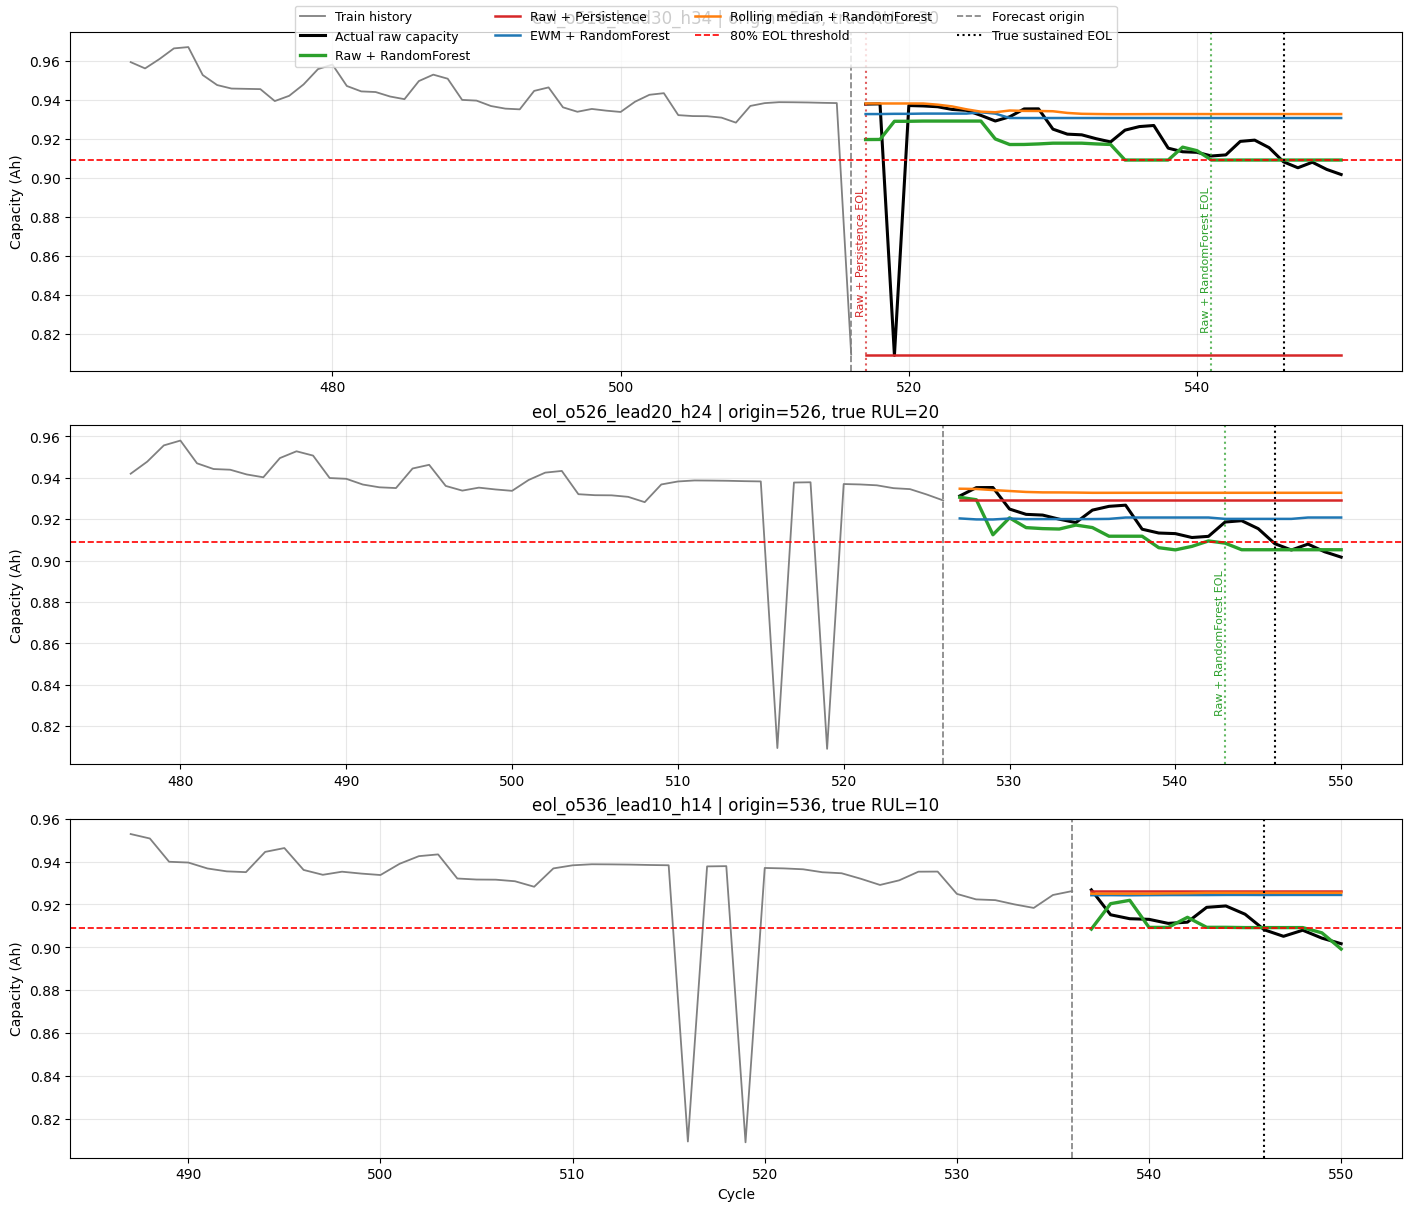

In [10]:
# 08-6. EOL/RUL 개선 결과 시각화

VISUAL_SCENARIOS = (
    scenarios[scenarios["scenario_type"] == "eol_crossing"]
    .sort_values("forecast_origin")
    ["scenario_id"]
    .tolist()
)

VISUAL_RUNS = [
    {
        "target_name": "capacity_raw",
        "model_name": "RandomForestRegressor",
        "label": "Raw + RandomForest",
        "color": "tab:green",
        "linewidth": 2.4,
    },
    {
        "target_name": "capacity_raw",
        "model_name": "Persistence",
        "label": "Raw + Persistence",
        "color": "tab:red",
        "linewidth": 1.8,
    },
    {
        "target_name": "capacity_ewm_span_9",
        "model_name": "RandomForestRegressor",
        "label": "EWM + RandomForest",
        "color": "tab:blue",
        "linewidth": 1.8,
    },
    {
        "target_name": "capacity_roll_median_7",
        "model_name": "RandomForestRegressor",
        "label": "Rolling median + RandomForest",
        "color": "tab:orange",
        "linewidth": 1.8,
    },
]

threshold_capacity = INITIAL_CAPACITY * EOL_THRESHOLD

fig, axes = plt.subplots(
    len(VISUAL_SCENARIOS),
    1,
    figsize=(14, 12),
    sharex=False,
    constrained_layout=True,
)

if len(VISUAL_SCENARIOS) == 1:
    axes = [axes]

for ax, scenario_id in zip(axes, VISUAL_SCENARIOS):
    scenario_row = scenarios[
        scenarios["scenario_id"] == scenario_id
    ].iloc[0]

    forecast_origin = int(scenario_row["forecast_origin"])
    true_eol_cycle = int(scenario_row["true_eol_cycle"])
    true_rul = int(scenario_row["true_rul"])

    train_tail = (
        series_df[series_df["cycle"] <= forecast_origin]
        .tail(50)
        .copy()
    )

    scenario_actual = (
        target_improvement_forecasts[
            target_improvement_forecasts["scenario_id"]
            == scenario_id
        ][["cycle", "y_true_capacity"]]
        .drop_duplicates()
        .sort_values("cycle")
    )

    ax.plot(
        train_tail["cycle"],
        train_tail["capacity_ah"],
        color="gray",
        linewidth=1.3,
        label="Train history",
    )

    ax.plot(
        scenario_actual["cycle"],
        scenario_actual["y_true_capacity"],
        color="black",
        linewidth=2.2,
        label="Actual raw capacity",
    )

    for run in VISUAL_RUNS:
        plot_df = (
            target_improvement_forecasts[
                (
                    target_improvement_forecasts["scenario_id"]
                    == scenario_id
                )
                & (
                    target_improvement_forecasts["target_name"]
                    == run["target_name"]
                )
                & (
                    target_improvement_forecasts["model_name"]
                    == run["model_name"]
                )
            ]
            .sort_values("cycle")
            .copy()
        )

        ax.plot(
            plot_df["cycle"],
            plot_df["y_pred_capacity"],
            color=run["color"],
            linewidth=run["linewidth"],
            label=run["label"],
        )

        pred_row = target_improvement_rul_predictions[
            (
                target_improvement_rul_predictions["scenario_id"]
                == scenario_id
            )
            & (
                target_improvement_rul_predictions["target_name"]
                == run["target_name"]
            )
            & (
                target_improvement_rul_predictions["model_name"]
                == run["model_name"]
            )
        ].iloc[0]

        if not pd.isna(pred_row["predicted_eol_cycle"]):
            ax.axvline(
                pred_row["predicted_eol_cycle"],
                color=run["color"],
                linestyle=":",
                alpha=0.75,
            )

            ax.text(
                pred_row["predicted_eol_cycle"],
                threshold_capacity * 0.985,
                f"{run['label']} EOL",
                color=run["color"],
                rotation=90,
                va="top",
                ha="right",
                fontsize=8,
            )

    ax.axhline(
        threshold_capacity,
        color="red",
        linestyle="--",
        linewidth=1.2,
        label="80% EOL threshold",
    )

    ax.axvline(
        forecast_origin,
        color="gray",
        linestyle="--",
        linewidth=1.2,
        label="Forecast origin",
    )

    ax.axvline(
        true_eol_cycle,
        color="black",
        linestyle=":",
        linewidth=1.5,
        label="True sustained EOL",
    )

    ax.set_title(
        f"{scenario_id} | origin={forecast_origin}, true RUL={true_rul}"
    )
    ax.set_ylabel("Capacity (Ah)")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Cycle")

handles, labels = axes[0].get_legend_handles_labels()
unique_legend = dict(zip(labels, handles))

fig.legend(
    unique_legend.values(),
    unique_legend.keys(),
    loc="upper center",
    ncol=4,
    fontsize=9,
)

plt.show()

### 분석 후 해석 포인트

`capacity_raw + RandomForestRegressor`는 EOL crossing 3개 중 2개를 탐지함. 특히 origin 516과 origin 526에서는 true EOL cycle 546에 비교적 가까운 cycle 541, 543을 예측을 함.

`capacity_raw + Persistence`는 origin 516에서 EOL을 탐지했지만, 예측 EOL cycle이 517로 너무 빨랐다. 이는 forecast origin 직전의 일시적 capacity drop을 그대로 반복했기 때문임.

`capacity_ewm_span_9`와 `capacity_roll_median_7`은 capacity trend를 안정적으로 만들지만, EOL threshold 아래로 내려가는 신호도 같이 완화됨. 따라서 pre-EOL trend 예측에는 도움이 되지만, 80% threshold 기반 EOL/RUL 탐지에는 불리하게 작동함.

이번 실험에서는 smoothed target을 최종 RUL 판단 target으로 쓰기보다, raw capacity 예측을 유지하고 RandomForestRegressor처럼 lag/rolling feature를 사용하는 방식이 더 적합하다고 해석할 수 있습니다.